# MPO Tensor network

In [803]:
import numpy as np
import qiskit.quantum_info as qi
from processtensor import QTensor, QuantumState, UnitarySE, ProcessTensor, Tensor
from qiskit.visualization import plot_state_hinton
from qiskit import QuantumCircuit

import quimb.tensor as qtn

In [804]:
I = np.eye(2)
X = qi.Pauli('X').to_matrix()
Y = qi.Pauli('Y').to_matrix()
Z = qi.Pauli('Z').to_matrix()

II = np.kron(I, I)
XX = np.kron(X, X)
YY = np.kron(np.conj(Y), Y)
ZZ = np.kron(Z, Z)

P = np.zeros((4, 4, 4), dtype=complex)
P[...,0] = II / 2
P[...,1] = XX / 2
P[...,2] = YY / 2
P[...,3] = ZZ / 2
P = Tensor(P)

$$
    \langle\!\bra{P} \Lambda \ket{P}\!\rangle \ket{P}\!\rangle\langle\!\bra{P} = (P \otimes P) \Lambda (P \otimes P)
$$

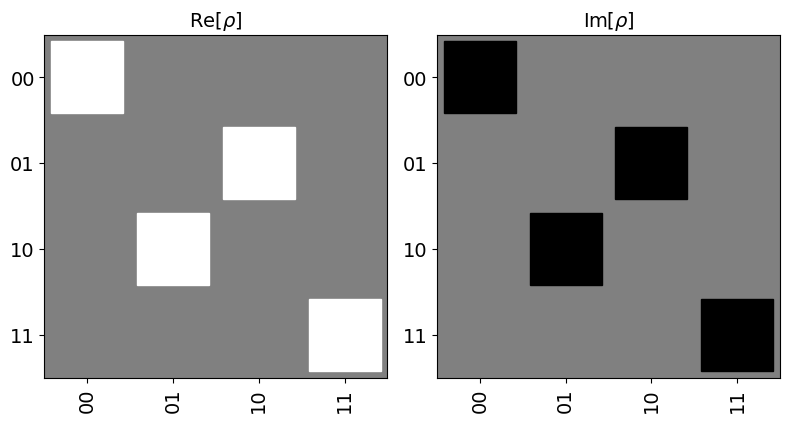

In [805]:
t = np.pi / 2
circuit = QuantumCircuit(2)
# circuit.h(0)
# circuit.h(1)
circuit.rxx(t, 0, 1)
circuit.ryy(t, 0, 1)
circuit.rzz(t, 0, 1)

h_unitary = unitary = qi.Operator(circuit).data
plot_state_hinton(h_unitary)

In [806]:
dS = 2
dE = 2

dS2 = dS * dS
dE2 = dE * dE
dS4 = dS2 * dS2
dE4 = dE2 * dE2

# unitary = qi.random_unitary(dS * dE).data
# unitary = np.eye(dS * dE)
unitary = h_unitary
U = UnitarySE.from_unitary(unitary, dS, dE)
rho_init = qi.random_density_matrix(dE)
# rho_init = qi.DensityMatrix(qi.random_statevector(dE))
r = QuantumState.from_matrix(rho_init.data, dE=dE)

U_init = r @ U
U_init = U_init.reshape(1, dS2, dS2, dE2)
# U_final = U.trace_subsystem(3)
U_final = Tensor(U.trace_subsystem(3).data / dE)

# Twirled tensors
V = U.link_product(P, [1, 2], [0, 1])
V_init = U_init.link_product(P, [1, 2], [0, 1]).reshape(dE2, 4)
V_final = U_final.link_product(P, [1, 2], [0, 1]).reshape(dE2, 4)


In [807]:
U_conj = Tensor(U.data.conj())
T = U.link_product(U_conj, [1, 2], [1, 2])
T = T.transpose(0, 2, 1, 3).reshape(dE4, dE4)
np.linalg.eigvals(T.data)
e = np.linalg.eigvals(T.data)
reals = e * np.conj(e)
reals.real / 16

array([1.65136439e-33, 1.00000000e+00, 3.79795575e-64, 1.47607748e-63,
       2.43086534e-63, 1.55361185e-96, 2.43086534e-63, 1.04156501e-96,
       2.43086534e-63, 5.83239867e-96, 3.03338409e-98, 4.00893736e-97,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [808]:
def calc_spectral_gap(V):
    V_conj = Tensor(V.data.conj())
    T = V.link_product(V_conj, 2, 2)
    T = T.transpose(0, 2, 1, 3).reshape(16, 16)
    e = np.linalg.eigvals(T.data)
    reals = e * np.conj(e)
    reals = reals.real / reals.real.max()
    sorted = np.sort(reals)[::-1]
    gap = 1 - sorted[1]
    return gap

def calc_heisenberg_tensor(t=np.pi / 2):
    circuit = QuantumCircuit(2)
    # circuit.h(0)
    # circuit.h(1)
    circuit.rxx(t, 0, 1)
    circuit.ryy(t, 0, 1)
    circuit.rzz(t, 0, 1)
    h_unitary = qi.Operator(circuit).data

    dS = 2
    dE = 2

    dS2 = dS * dS
    dE2 = dE * dE
    dS4 = dS2 * dS2
    dE4 = dE2 * dE2

    unitary = h_unitary

    U = UnitarySE.from_unitary(unitary, dS, dE)
    return U

def twirl_tensor(U):
    twirled = U.link_product(P, [1, 2], [0, 1])
    return twirled

In [809]:
dS = 2
dE = 2
unitary = qi.random_unitary(dS * dE).data
# U = UnitarySE.from_unitary(unitary, dS, dE)

U = calc_heisenberg_tensor(t=np.pi / 5)
V = twirl_tensor(U)
calc_spectral_gap(V)

np.float64(0.0)

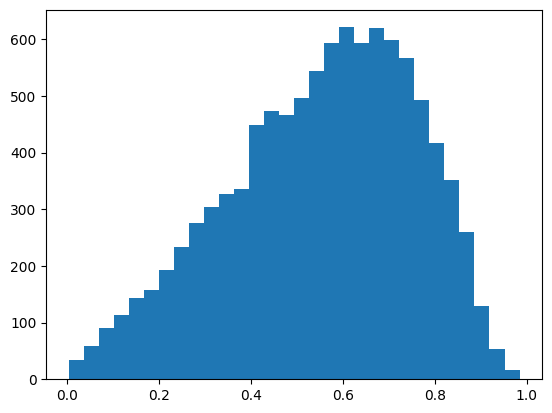

In [810]:
data = []
dS = 2
dE = 2
for i in range(10000):
    unitary = qi.random_unitary(dS * dE).data
    U = UnitarySE.from_unitary(unitary, dS, dE)
    V = twirl_tensor(U)
    gap = float(calc_spectral_gap(V))
    data.append(gap)

import matplotlib.pyplot as plt
fig = plt.hist(data, bins=30)

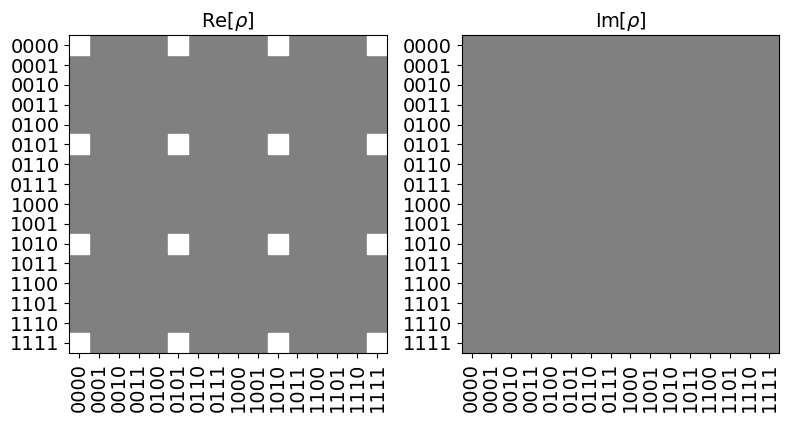

In [811]:
plot_state_hinton(T.data)

In [812]:
V_conj = Tensor(V.data.conj())
T = V.link_product(V_conj, 2, 2)
T = T.transpose(0, 1, 2, 3).reshape(16, 16)
e = np.linalg.eigvals(T.data)
reals = e * np.conj(e)
reals.real / reals.real.max()

array([1.00000000e+00, 2.08195386e-01, 1.68565144e-02, 1.98402732e-03,
       2.41292916e-33, 2.76660164e-33, 1.42829715e-33, 5.42933299e-34,
       3.45464771e-34, 4.01241766e-34, 5.08229108e-34, 2.47578450e-34,
       1.50258259e-34, 6.38804906e-35, 9.44727648e-35, 6.59269305e-36])

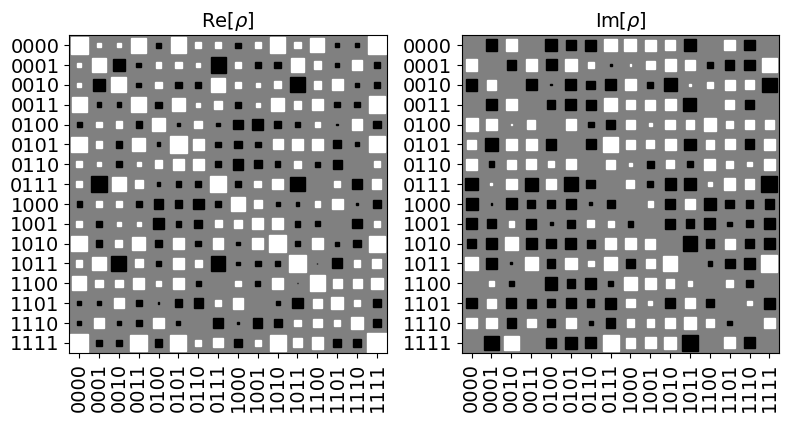

In [813]:
plot_state_hinton(T.data)

In [814]:
V.shape

(4, 4, 4)

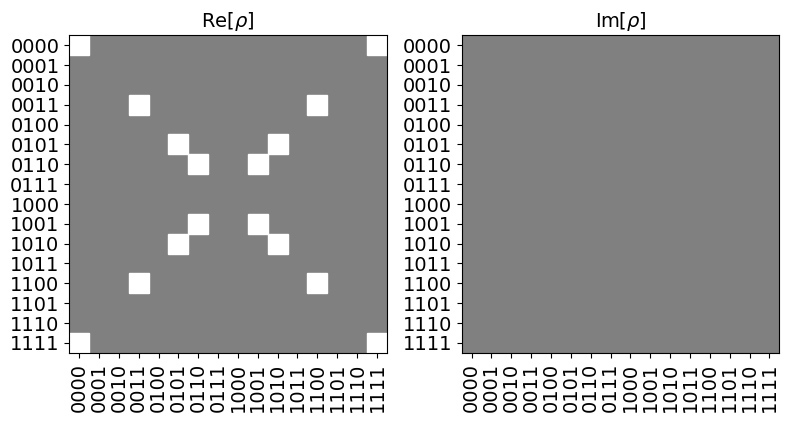

In [815]:
P_conj = Tensor(P.data.conj())
Y = P.link_product(P_conj, 2, 2)
Y = Y.transpose(0, 2, 1, 3).reshape(16, 16)
plot_state_hinton(Y.data)

In [816]:
M = QTensor(U_init).trace_subsystem(3).reshape(2, 2, 2, 2).transpose(0, 2, 1, 3).reshape(4, 4)
np.trace(M)

np.complex128(2+0j)

In [817]:
U_init = QTensor(U_init)
A = QTensor(U_init @ U).trace_subsystem(5)
A = A.link_product(P, [1, 2], [0, 1])
A = A.link_product(P, [1, 2], [0, 1])
A = A.reshape(16)
A

Tensor(data=[0.26208602+0.0000000e+00j 0.21466003+0.0000000e+00j
 0.40571813+6.9388939e-18j 0.24917341+0.0000000e+00j
 0.27290074+0.0000000e+00j 0.29897151+0.0000000e+00j
 0.26824755+0.0000000e+00j 0.29581548+0.0000000e+00j
 0.36647189+0.0000000e+00j 0.3869358 +0.0000000e+00j
 0.22368573+0.0000000e+00j 0.39653508+0.0000000e+00j
 0.09854135+0.0000000e+00j 0.09943267+0.0000000e+00j
 0.10234859-6.9388939e-18j 0.05847603+0.0000000e+00j])

In [818]:
pt = ProcessTensor(r @ U @ U @ U_final)
pt_choi = pt.choi_matrix

In [819]:
np.trace(pt_choi)

np.complex128(3.9999999999999987+2.168404344971009e-18j)

In [820]:
A0 = qtn.Tensor(U_init.reshape(dS4, dE2).data, inds=('s0', 'e1'), tags={'left'})
A1 = qtn.Tensor(U.reshape(dE2, dS4, dE2).data, inds=('e1', 's1', 'e2'), tags={'left'})
A2 = qtn.Tensor(U.reshape(dE2, dS4, dE2).data, inds=('e2', 's2', 'e3'), tags={'right'})
A3 = qtn.Tensor(U.trace_subsystem(3).reshape(dE2, dS2 * dS2).data, inds=('e3', 's3'), tags={'right'})

tn = qtn.TensorNetwork([A0, A1, A2, A3])

In [821]:
B0 = qtn.Tensor(V_init.data, inds=('e1', 'x0'), tags={'A0'})
B1 = qtn.Tensor(V.data, inds=('e1', 'e2', 'x1'), tags={'A1'})
B2 = qtn.Tensor(V.data, inds=('e2', 'e3', 'x2'), tags={'A2'})
B3 = qtn.Tensor(V_final.data, inds=('e3', 'x3'), tags={'A3'})

tn_twirl = qtn.TensorNetwork([B0, B1, B2, B3])

In [822]:
spc = tn_twirl.view_as(qtn.MatrixProductState, site_tag_id='A{}', site_ind_id='x{}', cyclic=False, L=4)

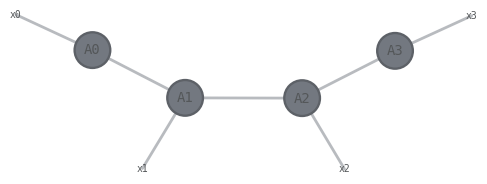

In [823]:
spc.draw()

In [824]:
spc.tensors

(Tensor(shape=(4, 4), inds=('e1', 'x0'), tags=oset(['A0'])),
 Tensor(shape=(4, 4, 4), inds=('e1', 'e2', 'x1'), tags=oset(['A1'])),
 Tensor(shape=(4, 4, 4), inds=('e2', 'e3', 'x2'), tags=oset(['A2'])),
 Tensor(shape=(4, 4), inds=('e3', 'x3'), tags=oset(['A3'])))

In [825]:
spc = spc.left_canonicalize()

In [826]:
spc

MatrixProductState(tensors=4, indices=7, L=4, max_bond=4)

In [827]:
T = spc.tensors[0].data

In [828]:
# Check minimal bond dimension across middle cut

tn_left = tn.select(['left'])
tn_right = tn.select(['right'])
left = tn_left.contract()
right = tn_right.contract()

M = qtn.tensor_contract(left, right)
M = M.data.reshape(256, 256)
np.linalg.matrix_rank(M) 

np.int64(4)

In [829]:
U_conj = QTensor(U.data.conj())
V_conj = Tensor(V.data.conj())

W = U.link_product(U_conj, [0, 3], [0, 3])
W_twirl = V.link_product(V_conj, [0, 1], [0, 1])

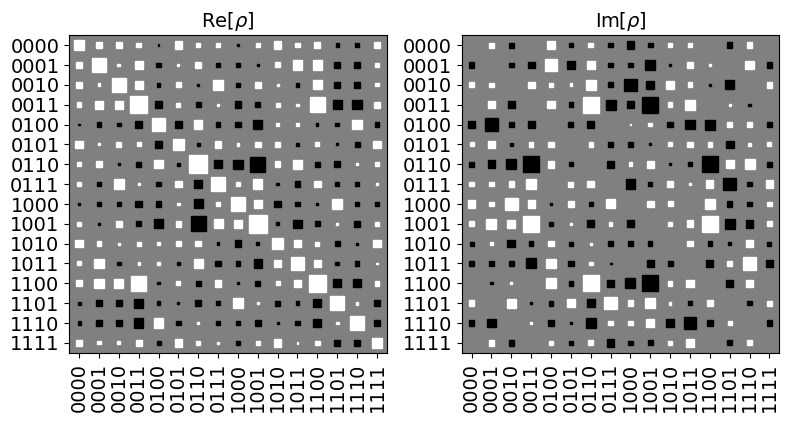

In [830]:
plot_state_hinton(W.reshape(dS4, dS4).data)

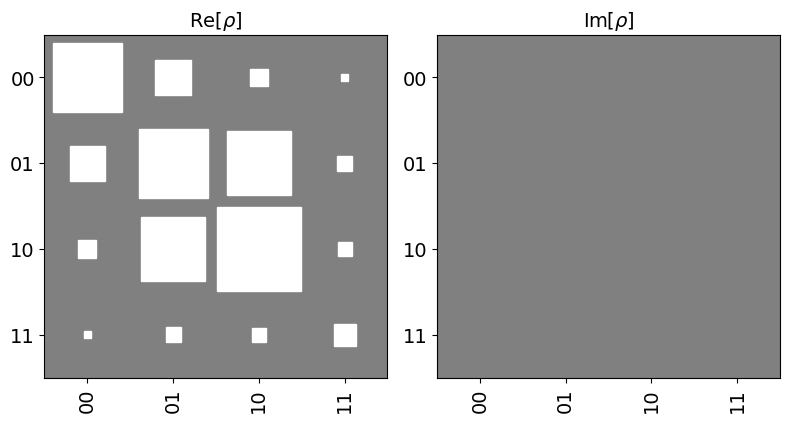

In [831]:
plot_state_hinton(W_twirl.data)

# Canonicalisation

In [832]:
S = np.sum(V, axis=2)
print(f'S = {S}')

w, vr = np.linalg.eig(S)
print(f'eigenvalues = {w}')

S = [[ 1.11081872+0.j         -0.16717006+0.51989754j -0.16717006-0.51989754j
   0.88918128+0.j        ]
 [ 0.04019965+0.37133892j  0.85387098+0.38931258j  0.10697055-0.4291403j
  -0.04019965-0.37133892j]
 [ 0.04019965-0.37133892j  0.10697055+0.4291403j   0.85387098-0.38931258j
  -0.04019965+0.37133892j]
 [ 0.88918128+0.j          0.16717006-0.51989754j  0.16717006+0.51989754j
   1.11081872+0.j        ]]
eigenvalues = [0.38643781-9.05263008e-01j 0.38643781+9.05263008e-01j
 2.        -6.34043221e-17j 1.15650378+1.07081732e-16j]
